<a href="https://colab.research.google.com/github/siwell24/Portofolio-Wildan/blob/main/Peta_Titik_Bencana_Provinsi_Aceh_29_09_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EPSG:32647
Tabel Laporan Bencana :
     Laporan           WADMKK
0  Laporan 1  Kota Banda Aceh
1  Laporan 2      Aceh Tengah
2  Laporan 3        Gayo Lues
--- Membuat Zona Buffer 10 km ---
--- Membuat Zona Buffer 10 km dari Titik Bencana ---


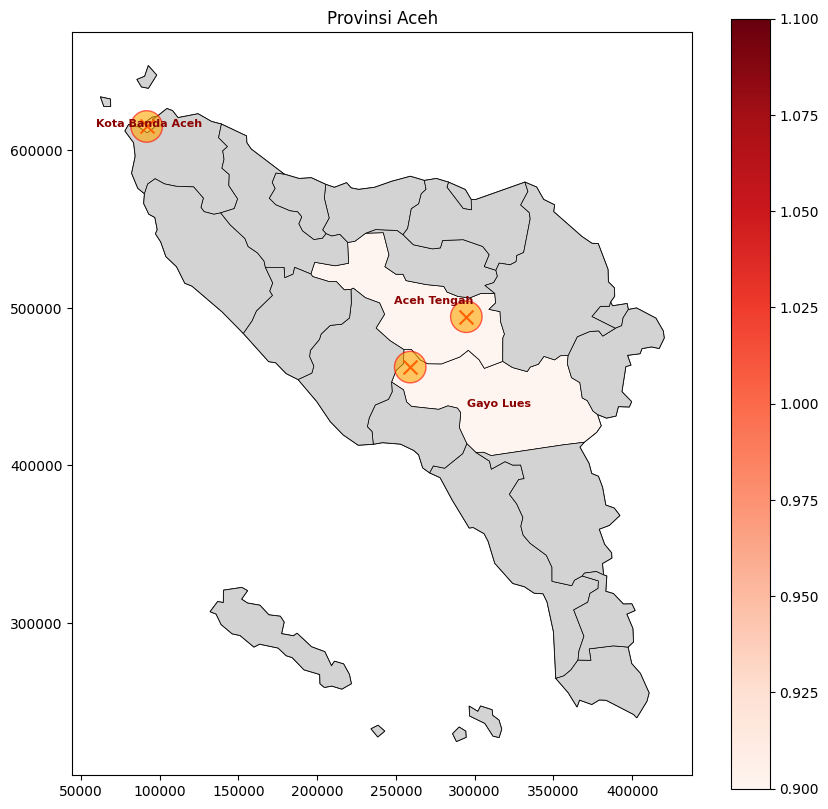

In [13]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

nama_file = "/content/drive/MyDrive/Learning Phyton/Provinsi Indonesia/38 Provinsi Indonesia - Kabupaten.json"
indonesia = gpd.read_file(nama_file)
provinsi_aceh = indonesia[indonesia["WADMPR"] == "Aceh"]

aceh_utm = provinsi_aceh.estimate_utm_crs()
provinsi_aceh_utm = provinsi_aceh.to_crs(aceh_utm)
print (aceh_utm)

# Data for the points
data_points_dict = {
    "Laporan": [
        "Laporan 1",
        "Laporan 2",
        "Laporan 3"
    ],
    "Keterangan": [
        "Longsor",
        "Banjir Bandan",
        "Gempa Bumi"
    ],
    'latitude': [5.5536, 4.47, 4.18],
    'longitude': [95.3171, 97.15, 96.83],
}

# Create a GeoDataFrame from the dictionary, explicitly setting geometry and crs
data_titik_laporan = gpd.GeoDataFrame(
    data_points_dict,
    geometry=gpd.points_from_xy(data_points_dict['longitude'], data_points_dict['latitude']),
    crs="EPSG:4326",
)

# Reproject data_titik_laporan to match the CRS of provinsi_aceh_utm
data_titik_laporan = data_titik_laporan.to_crs(aceh_utm)

# Perform sjoin using data_titik_laporan and provinsi_aceh_utm (both in aceh_utm CRS)
hasil_sjoin = gpd.sjoin(data_titik_laporan, provinsi_aceh_utm, how = "inner", predicate="within")
print("Tabel Laporan Bencana :")
print(hasil_sjoin[["Laporan", "WADMKK"]])

#BUFFERING
print("--- Membuat Zona Buffer 10 km ---")
# Create a buffered version of provinsi_aceh_utm
# BUFFERING PADA TITIK LAPORAN
print("--- Membuat Zona Buffer 10 km dari Titik Bencana ---")

# Buat buffer 10 km (10.000 meter) dari geometri titik laporan yang sudah UTM
titik_buffer = data_titik_laporan.geometry.buffer(10000)

# Masukkan kembali ke GeoDataFrame agar bisa di-plot
data_titik_buffer = data_titik_laporan.copy()
data_titik_buffer["geometry"] = titik_buffer

fig, ax = plt.subplots(figsize=(10,10))
rekap_size = (
    hasil_sjoin.groupby("WADMKK").size().reset_index(name="jumlah_laporan")
)

# Merge rekap_size with the *unbuffered* provinsi_aceh_utm for choropleth mapping
provinsi_aceh_merged = provinsi_aceh_utm.merge(
    rekap_size, on="WADMKK", how="left"
)

# Plot the original province boundaries (from provinsi_aceh_utm)
provinsi_aceh_utm.plot(
    ax=ax, facecolor="lightgray", edgecolor="black", linewidth = 0.8
)

provinsi_aceh_merged.plot (
    column = "jumlah_laporan",
    cmap = "Reds",
    legend = True,
    ax = ax,
    edgecolor = "black",
    linewidth = 0.5,
    linestyle = "-",
    missing_kwds= {
        "color": "lightgray",
        "edgecolor": "black",
        "label": "Tidak Ada Laporan",
    },
)
data_titik_laporan.plot(
    ax=ax, color="red", marker  = "x", markersize= 100,
)
titik_buffer.plot(
    ax=ax,
    color="orange",
    edgecolor="red",
    alpha=0.6,
    label="Buffer 10 km (Kab. Besar)",
)
for idx, row in provinsi_aceh_merged.iterrows():
  if pd.notna(row["jumlah_laporan"]) and row["jumlah_laporan"] :
    titik_tengah = row.geometry.representative_point()

    ax.text(
        titik_tengah.x,
        titik_tengah.y,
        f"{row['WADMKK']}",
        fontsize=8,
        ha="center",
        va="center",
        weight="bold",
        color="darkred",
    )
plt.title ("Provinsi Aceh")
plt.show()